#### 1.- Encuentra el espectro de potencias en 1d, 2d y 3d para la función de correlación

a) Para 1D:

$$ P(k)=2\int_0^\infty \left( \frac{r}{r_0} \right)^{-\gamma} \cos(kr) dr $$

De la propiedad 

$$\int_0^\infty x^\mu\cos(ax)dx=\Gamma(\mu+1)\cos\left(  \frac{\pi(\mu+1)}{2} \right)$$

Entonces, $$P(k)=2\int_0^\infty \left( \frac{r}{r_0} \right)^{-\gamma} \cos(kr) dr=2k^{\gamma-1}\Gamma(1-\gamma)\cos\left(\frac{\pi(1-\gamma)}{2}\right)$$
$$  \therefore P(k)=2r_0^\gamma \Gamma(1-\gamma)\cos\left( \frac{\pi r}{2} \right)  k^{\gamma-1} $$

b) Para 2D:

$$ P(k)=2\pi r_0^\gamma \int_0^\infty r^{-\gamma+1}J_0(k r) dr $$

De la propiedad 

$$\int_0^\infty x^\mu J_v(ax) dx=\frac{a^{-\mu-1} \Gamma((1+\mu+v)/2)}{2^\mu\Gamma((1+v-\mu)/2)}$$

Entonces, $$P(k)=2\pi r_0^\gamma \int_0^\infty r^{-\gamma+1}J_0(k r) dr= 2\pi r_0^\gamma k^{\gamma-2} \frac{\Gamma((2-\gamma)/2)}{2^{-\gamma+1}\Gamma(\gamma/2)}    $$
$$  \therefore P(k)= (2 r_0)^\gamma \pi \frac{\Gamma(1-\gamma/2)}{\Gamma(\gamma/2)} k^{\gamma-2}  $$

b) Para 3D:

$$ P(k)=\frac{4\pi r_0^\gamma}{k} \int_0^\infty r^{-\gamma+1}\sin(k r) dr $$

De la propiedad 

$$\int_0^\infty x^{\mu-1} \sin(ax) dx=a^{-\mu}\Gamma(\mu)\sin\left(\frac{\pi\mu}{2}\right)$$

Entonces, $$P(k)=\frac{4\pi r_0^\gamma}{k} \int_0^\infty r^{-\gamma+1}\sin(k r) dr= 4\pi k^{\gamma-3} r_0^\gamma \Gamma(2-\gamma) \sin(\pi\gamma/2)    $$
$$  \therefore P(k)= 4\pi r_0^\gamma \Gamma(2-\gamma) \sin\left(\frac{\pi\gamma}{2}\right)  k^{\gamma-3}  $$

#### 2.- Calcula el espectro de potencias para las distribuciones de Funciones_Correlacion.ipynb

In [126]:
import sympy as owo
import numpy as uwu
import matplotlib as mlp
import matplotlib.pyplot as plt
from scipy import special
import math
import pandas as pd
import matplotlib.ticker as ticker
from mpl_toolkits.mplot3d import Axes3D

#Definicion de las funciones
#for theta_k in uwu.linspace(0,2*uwu.pi,100, endpoint=False):
#for i in range(N):
def P_k_punto(k,bin_ang,N,V,distribucion): #Espectro de Potencia
    sum_exp_promang=0
    for theta_k in uwu.linspace(0,2*uwu.pi,bin_ang, endpoint=False):
        suma_exp=0
        for i in range(N):
            mag_punto_dis=uwu.sqrt(distribucion[i,0]**2+distribucion[i,1]**2)
            ang_dis=math.atan2(distribucion[i,1], distribucion[i,0])
            suma_exp+=uwu.exp( -1j * k * mag_punto_dis * uwu.cos(theta_k-ang_dis)  )
        Nor_suma_exp=suma_exp/N
        P_k_theta=uwu.real(V * Nor_suma_exp * uwu.conj(Nor_suma_exp) - V/N)
        sum_exp_promang+=P_k_theta
    Nor_sum_exp_promang=sum_exp_promang/bin_ang
    return Nor_sum_exp_promang

def generar_malla(ancho, alto, distancia=100): #Malla Cuadriculada
    
    puntos_malla = uwu.vstack([(x, y) for x in range(0, ancho + 1, distancia) 
    for y in range(0, alto + 1, distancia)]) #La 'distancia' en range, genera el espaciado desado en la generacion de cada punto
    return puntos_malla

def spawn_puntos_disco(n, t, r,centro): #Distribucion de disco
        #Centro debe ser un punto en el plano.
        angulos = uwu.random.uniform(0, 2*uwu.pi, n) #Genera angulos entre 0 a 2\pi
        radios = uwu.random.uniform(0, r, n)   # Generar radios de 0 a r NOTA: Se debe cambiar a radios al cuadrado para dar una distribucion uniforme
        x = radios * uwu.cos(angulos) #Transformacion de polares a cartesianas
        y = radios * uwu.sin(angulos)
        x += centro[0]  #Traslada el centro a las coordenadas de eleccion 
        y += centro[1]
        puntos = uwu.vstack((x, y)).T   #Ordena los datos en una matriz de n x 2
        return puntos

def spawn_puntos_anillo(n, t, rm,rM,centro): #Distribucion de anillo
        #Centro debe ser un punto en el plano.
    
        angulos = uwu.random.uniform(0, 2*uwu.pi, n) #Genera angulos entre 0 a 2\pi
        radios = uwu.random.uniform(rm, rM, n)   # Generar radios de 0 a r, rm es el radio menor y rM el radio mayor del anillo
        x = radios * uwu.cos(angulos) #Transformacion de polares a cartesianas
        y = radios * uwu.sin(angulos)
        x += centro[0]  #Traslada el centro a las coordenadas de eleccion 
        y += centro[1]
        puntos = uwu.vstack((x, y)).T   #Ordena los datos en una matriz de n x 2
        return puntos

def anillos_distribuidos(num_centros, tam,r1,r2,num_p): #Distribucion de anillos
    plt.figure(figsize=(8, 8)) #Inicia la figura
    puntos_anillos = [] #Lista que guardara todos los puntos generados
    for i in range(num_centros):
        centro=(uwu.random.uniform(0, tam), uwu.random.uniform(0, tam)) #Genera el centro aleatorio
        p = spawn_puntos_anillo(num_p, tam,r1,r2,centro) #Genera los puntos, segun las caracteristicas anteriores
        puntos_anillos.append(p) #Va guardando cada anillo en la lista 
        #plt.scatter(p[:,0], p[:,1], alpha=0.5, s=5, color='blue') #Grafica el anillo generado de cada iteracion
    puntos_anillos = uwu.vstack(puntos_anillos) if puntos_anillos else uwu.array([]) # Transforma la lista de arrays en un solo array usando vstack
    return puntos_anillos

def grafica_3d(p,tam): #Grafica los puntos aleatorios en 3d
    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(p[:,0], p[:,1], p[:,2], alpha=0.5) #Toma los valores en x, y, z en el spawn de puntos y los grafica
    ax.set_xlim([0, tam])
    ax.set_ylim([0, tam])
    ax.set_zlim([0, tam])
    ax.set_title("Distribucion Aleatoria en 3D")
    plt.show()

L=1000 #Tamaño de caja
V=L*L #Volumen de malla (2 dimensiones)


##### Malla Cuadriculada

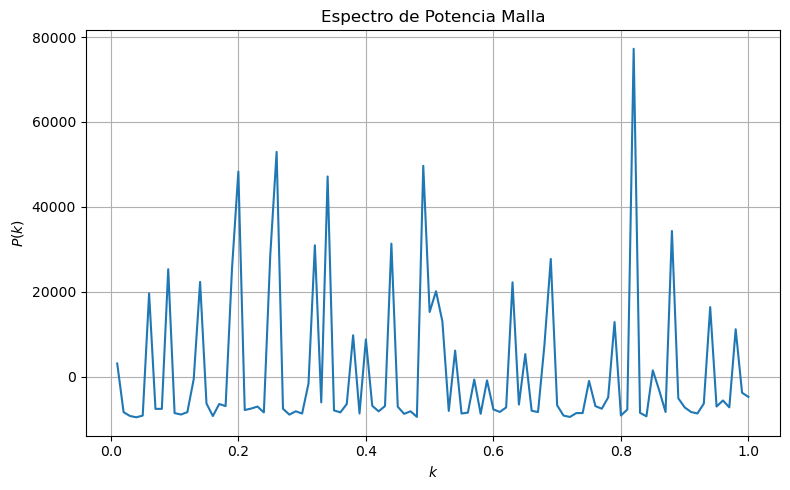

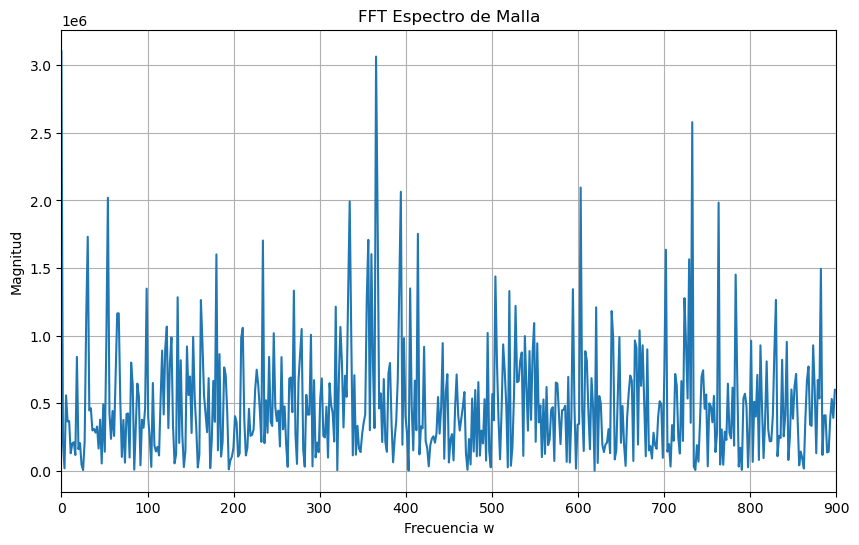

In [129]:
N=100 #Numero de puntos generados en la malla
P_k_Malla=[]
bines_k= uwu.linspace(0.01,1,100)
bin_ang=100 #Numero de bines en angulos


for k in bines_k: #Calcula la funcion para un rango de k
    pk=P_k_punto(k,bin_ang,N,V,Malla)
    P_k_Malla.append(pk)
    

plt.figure(figsize=(8, 5))
plt.plot(bines_k, P_k_Malla, label='')
plt.xlabel('$k$')
plt.ylabel('$P(k)$')
plt.title('Espectro de Potencia Malla')
plt.grid(True)
plt.tight_layout()
plt.show()

# Calcula la transformada de Fourier del espectro

N_tiempo= 1000  # Número de puntos en el espacio temporal
N_w2=1000 #Numero de puntos en el espacio de frecuencias
N_w=1800 #Numero que determina el rango donde se va a graficar en el espacio de frecuencias de 0 a N_w/2
dw = 1/N_w  # Intervalo de muestreo en el espacio de frecuencias

t = uwu.linspace(-25, 25, N_tiempo) #Eje temporal
freqs = uwu.fft.fftfreq(N_w2, dw) #Genera el eje de las frecuencias
freqs_shifted = uwu.fft.fftshift(freqs) #Desplaza el eje de frecuencias para que sea alrededor del cero.

y1 = P_k_punto(t,bin_ang,N,V,Malla)
Y1= uwu.fft.fft(y1) #Calcula la transformada rapida
Y1_shift=uwu.fft.fftshift(Y1) #Shiftea los valores de Y para que coincidan con los del shift en la frecuencia shifteada


# Grafica la FFT
plt.figure(figsize=(10, 6))
plt.plot(freqs_shifted, uwu.abs(Y1_shift), label='')
plt.xlabel("Frecuencia w")
plt.ylabel("Magnitud")
plt.title("FFT Espectro de Malla")
plt.grid(True)
plt.xlim([0, 900])
plt.show()


##### Disco

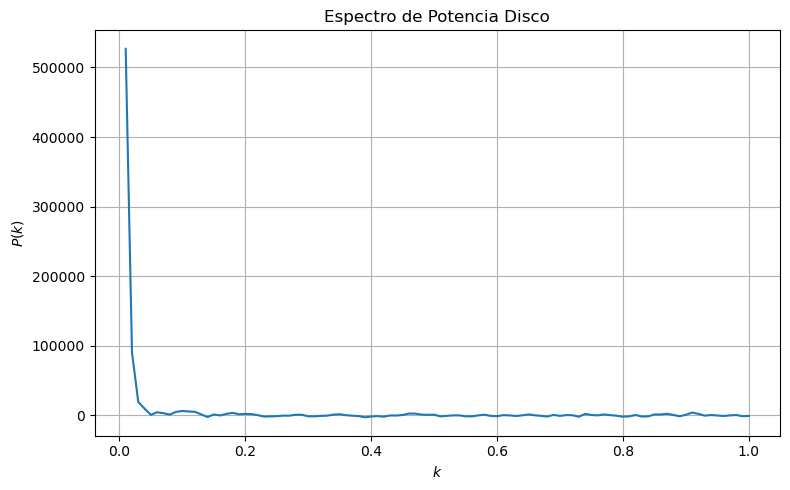

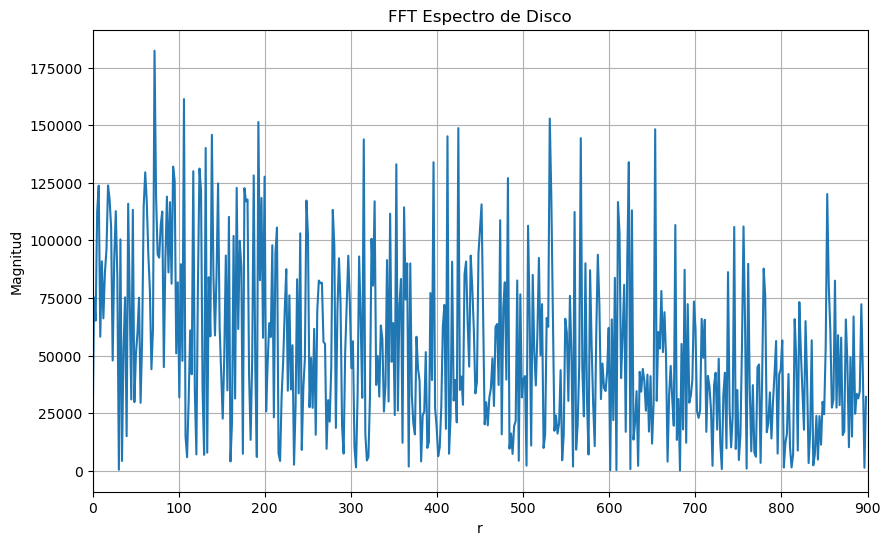

In [131]:

bines_k= uwu.linspace(0.01,1,100) 
bin_ang=100 #Numero de bines en angulos

r=200 #Radio
num_p = 1000  # Cantidad de puntos
tam=1000   #Tamaño del grafico
centro=(300, 500) #Centro donde se generan los puntos del disco 

Disco = spawn_puntos_disco(num_p, tam,r,centro) #Genera los puntos, segun las caracteristicas anteriores

P_k_Disco=[]

for k in bines_k: #Calcula la funcion para un rango de k
    pk=P_k_punto(k,bin_ang,N,V,Disco)
    P_k_Disco.append(pk)
    

plt.figure(figsize=(8, 5))
plt.plot(bines_k, P_k_Disco, label='')
plt.xlabel('$k$')
plt.ylabel('$P(k)$')
plt.title('Espectro de Potencia Disco')
plt.grid(True)
plt.tight_layout()
plt.show()

# Calcula la transformada de Fourier del espectro

N_tiempo= 1000  # Número de puntos en el espacio temporal
N_w2=1000 #Numero de puntos en el espacio de frecuencias
N_w=1800 #Numero que determina el rango donde se va a graficar en el espacio de frecuencias de 0 a N_w/2
dw = 1/N_w  # Intervalo de muestreo en el espacio de frecuencias

t = uwu.linspace(-25, 25, N_tiempo) #Eje temporal
freqs = uwu.fft.fftfreq(N_w2, dw) #Genera el eje de las frecuencias
freqs_shifted = uwu.fft.fftshift(freqs) #Desplaza el eje de frecuencias para que sea alrededor del cero.

y1 = P_k_punto(t,bin_ang,N,V,Disco)
Y1= uwu.fft.fft(y1) #Calcula la transformada rapida
Y1_shift=uwu.fft.fftshift(Y1) #Shiftea los valores de Y para que coincidan con los del shift en la frecuencia shifteada


# Grafica la FFT
plt.figure(figsize=(10, 6))
plt.plot(freqs_shifted, uwu.abs(Y1_shift), label='')
plt.xlabel("r")
plt.ylabel("Magnitud")
plt.title("FFT Espectro de Disco")
plt.grid(True)
plt.xlim([0, 900])
plt.show()

#### Anillo

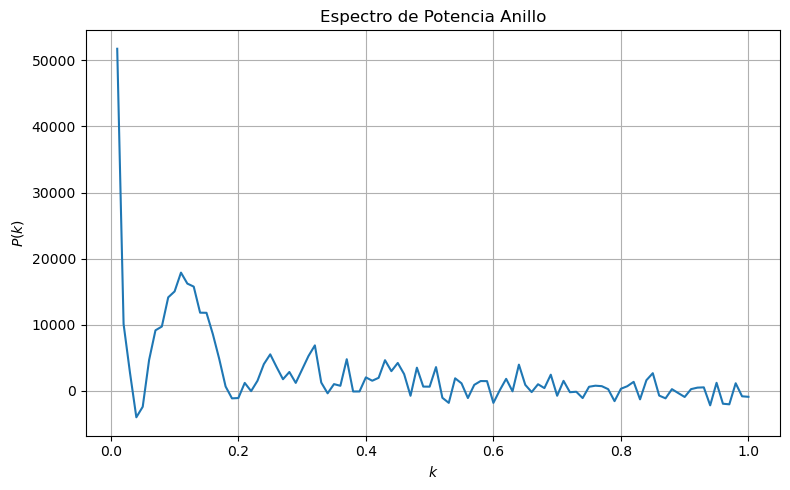

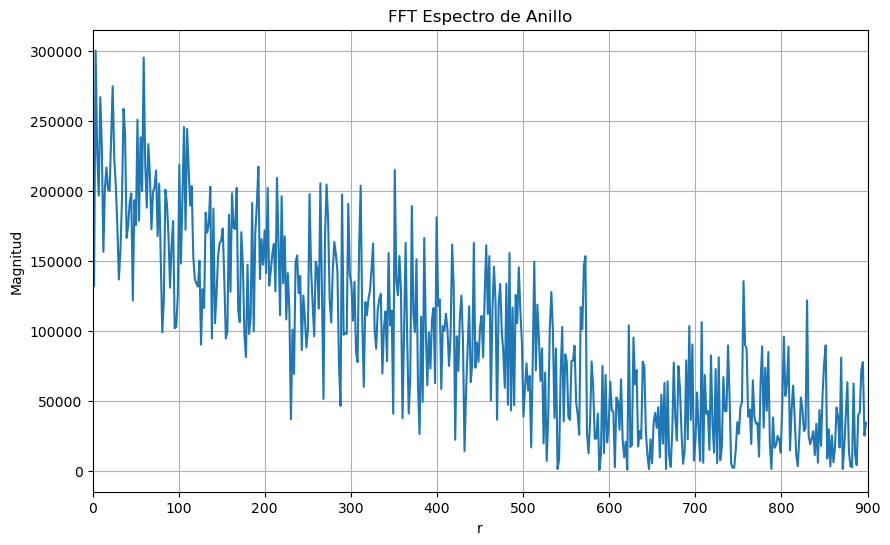

In [133]:

bines_k= uwu.linspace(0.01,1,100) 
bin_ang=100 #Numero de bines en angulos

r1=290 #Radio menor
r2=300 #Radio mayor
num_p = 1000  # Cantidad de puntos
tam=1000   #Tamaño del grafico
centro=(400, 500) #Centro donde se generan los puntos del disco 

Anillo= spawn_puntos_anillo(num_p, tam,r1,r2,centro) #Genera los puntos, segun las caracteristicas anteriores

P_k_Anillo=[]

for k in bines_k: #Calcula la funcion para un rango de k
    pk=P_k_punto(k,bin_ang,N,V,Anillo)
    P_k_Anillo.append(pk)
    

plt.figure(figsize=(8, 5))
plt.plot(bines_k, P_k_Anillo, label='')
plt.xlabel('$k$')
plt.ylabel('$P(k)$')
plt.title('Espectro de Potencia Anillo')
plt.grid(True)
plt.tight_layout()
plt.show()

# Calcula la transformada de Fourier del espectro

N_tiempo= 1000  # Número de puntos en el espacio temporal
N_w2=1000 #Numero de puntos en el espacio de frecuencias
N_w=1800 #Numero que determina el rango donde se va a graficar en el espacio de frecuencias de 0 a N_w/2
dw = 1/N_w  # Intervalo de muestreo en el espacio de frecuencias

t = uwu.linspace(-25, 25, N_tiempo) #Eje temporal
freqs = uwu.fft.fftfreq(N_w2, dw) #Genera el eje de las frecuencias
freqs_shifted = uwu.fft.fftshift(freqs) #Desplaza el eje de frecuencias para que sea alrededor del cero.

y1 = P_k_punto(t,bin_ang,N,V,Anillo)
Y1= uwu.fft.fft(y1) #Calcula la transformada rapida
Y1_shift=uwu.fft.fftshift(Y1) #Shiftea los valores de Y para que coincidan con los del shift en la frecuencia shifteada


# Grafica la FFT
plt.figure(figsize=(10, 6))
plt.plot(freqs_shifted, uwu.abs(Y1_shift), label='')
plt.xlabel("r")
plt.ylabel("Magnitud")
plt.title("FFT Espectro de Anillo")
plt.grid(True)
plt.xlim([0, 900])
plt.show()

#### Anillos

<Figure size 800x800 with 0 Axes>

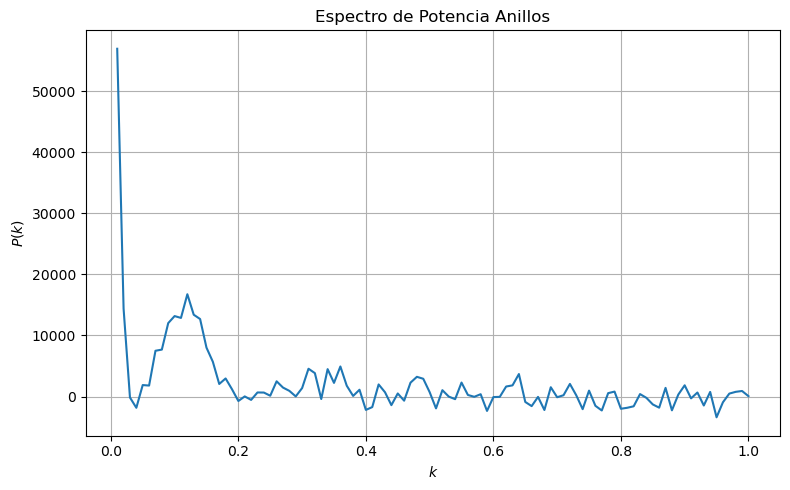

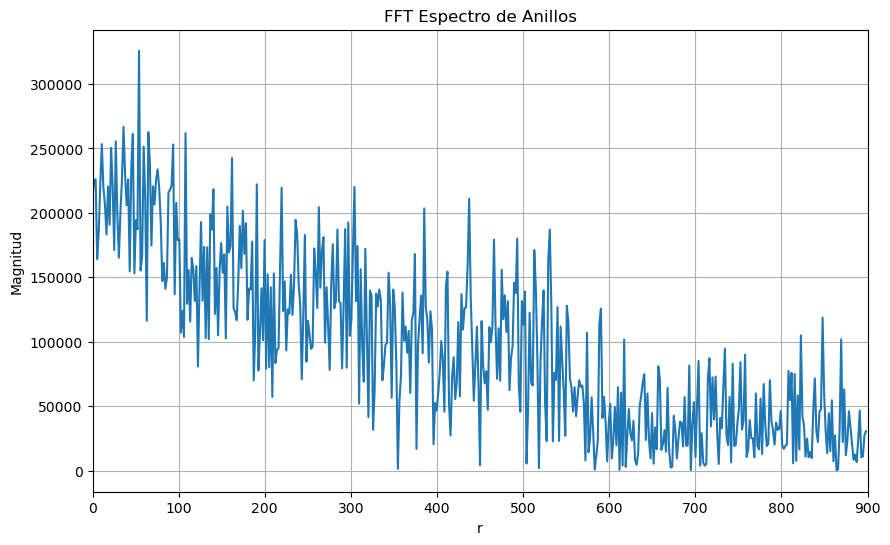

In [135]:

bines_k= uwu.linspace(0.01,1,100) 
bin_ang=100 #Numero de bines en angulos

r1=290 #Radio menor de los anillos
r2=300 #Radio mayor
num_pa = 100  # Cantidad de puntos en cada anillo
tam=1000   #Tamaño del grafico
num_centros=50 #Numero de centros o anillos a graficar

Anillos=anillos_distribuidos(num_centros,tam,r1,r2,num_pa)

P_k_Anillos=[]

for k in bines_k: #Calcula la funcion para un rango de k
    pk=P_k_punto(k,bin_ang,N,V,Anillos)
    P_k_Anillos.append(pk)
    

plt.figure(figsize=(8, 5))
plt.plot(bines_k, P_k_Anillos, label='')
plt.xlabel('$k$')
plt.ylabel('$P(k)$')
plt.title('Espectro de Potencia Anillos')
plt.grid(True)
plt.tight_layout()
plt.show()

# Calcula la transformada de Fourier del espectro

N_tiempo= 1000  # Número de puntos en el espacio temporal
N_w2=1000 #Numero de puntos en el espacio de frecuencias
N_w=1800 #Numero que determina el rango donde se va a graficar en el espacio de frecuencias de 0 a N_w/2
dw = 1/N_w  # Intervalo de muestreo en el espacio de frecuencias

t = uwu.linspace(-25, 25, N_tiempo) #Eje temporal
freqs = uwu.fft.fftfreq(N_w2, dw) #Genera el eje de las frecuencias
freqs_shifted = uwu.fft.fftshift(freqs) #Desplaza el eje de frecuencias para que sea alrededor del cero.

y1 = P_k_punto(t,bin_ang,N,V,Anillos)
Y1= uwu.fft.fft(y1) #Calcula la transformada rapida
Y1_shift=uwu.fft.fftshift(Y1) #Shiftea los valores de Y para que coincidan con los del shift en la frecuencia shifteada


# Grafica la FFT
plt.figure(figsize=(10, 6))
plt.plot(freqs_shifted, uwu.abs(Y1_shift), label='')
plt.xlabel("r")
plt.ylabel("Magnitud")
plt.title("FFT Espectro de Anillos")
plt.grid(True)
plt.xlim([0, 900])
plt.show()